# Whole-night qualitative figure -- MM-Net on a representative held-out subject (SN90)

Three panels, all produced live from the data and the trained model:

- **A.** Predicted vs. reference hypnogram for the full night.
- **B.** EEG spectrogram (central derivation) from the raw recording.
- **C.** The model's per-epoch stage-probability ribbon, with its confidence (max posterior).

**Subject choice.** SN90 is a *representative* night: its per-subject staging accuracy sits on the
cohort mean (~0.72), so the figure is neither a best-case nor a worst-case cherry-pick.

**Protocol.** SN90 is genuinely held out: we train the one patient-independent fold (seed 42, the
same split as the headline run) whose test set contains SN90, then infer. One fold, ~90 s. All
model, training, and inference code is inlined below -- the notebook is self-contained.

In [1]:
import os, glob, warnings, numpy as np
import torch, torch.nn as nn
from sklearn.metrics import accuracy_score, cohen_kappa_score
import mne, scipy.signal as sg
import matplotlib.pyplot as plt
from matplotlib import gridspec
warnings.filterwarnings("ignore")
mne.set_log_level("ERROR")

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "revision" else os.getcwd()
FE   = os.path.join(ROOT, "data", "mm_features")
EDFS = {os.path.basename(f)[:-4]: f for f in glob.glob(os.path.join(ROOT, "data", "Dataset", "**", "*.edf"), recursive=True)}
FIGDIR = os.path.join(ROOT, "results", "revision", "figures"); os.makedirs(FIGDIR, exist_ok=True)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
L, NC, EPS, SEED = 20, 5, 1e-12, 42
CLS = ["W", "N1", "N2", "N3", "R"]         # label index -> stage
DUPLICATE_DROP = {28}                        # SN28 is a byte-duplicate of SN15
torch.manual_seed(SEED); np.random.seed(SEED)
torch.backends.cudnn.deterministic = True    # reproducible single-fold retrain (stable figure)
torch.backends.cudnn.benchmark = False
print("device:", DEV, "| EDFs found:", len(EDFS))

device: cuda | EDFs found: 97


In [2]:
class FeatMLP(nn.Module):
    """Two-layer MLP with LayerNorm: a feature vector -> dense embedding."""
    def __init__(self, fin, d, drop):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(fin, d), nn.LayerNorm(d), nn.GELU(), nn.Dropout(drop),
            nn.Linear(d, d), nn.LayerNorm(d), nn.GELU(), nn.Dropout(drop))
    def forward(self, x): return self.net(x)

class CrossFusion(nn.Module):
    def __init__(self, d, heads=4, drop=0.3):
        super().__init__()
        self.mtype = nn.Parameter(torch.randn(2, d) * 0.02)
        self.attn = nn.MultiheadAttention(d, heads, dropout=drop, batch_first=True)
        self.norm = nn.LayerNorm(d)
        self.ff = nn.Sequential(nn.Linear(2 * d, d), nn.GELU(), nn.Dropout(drop))
    def forward(self, e, cc):
        tok = torch.stack([e, cc], 1) + self.mtype[None]
        a, _ = self.attn(tok, tok, tok); a = self.norm(tok + a)
        return self.ff(a.reshape(a.size(0), -1))

class MMFeatureNet(nn.Module):
    """The headline model (concat fusion): two feature streams -> fuse -> BiLSTM -> {stage, apnea}.
    The apnea head reads a DIRECT copy of the per-epoch cardio embedding."""
    def __init__(self, n_eeg=188, n_card=14, d=128, d_card=64, hidden=128, layers=2,
                 n_cls=5, drop=0.3, fusion="concat"):
        super().__init__()
        self.fusion = fusion
        self.eeg_enc = FeatMLP(n_eeg, d, drop); self.card_enc = FeatMLP(n_card, d_card, drop)
        if fusion == "cross":
            self.card_proj = nn.Linear(d_card, d); self.fuse = CrossFusion(d, drop=drop)
        elif fusion == "concat":
            self.fuse = nn.Sequential(nn.Linear(d + d_card, d), nn.GELU(), nn.Dropout(drop))
        else:
            self.fuse = nn.Sequential(nn.Linear(d, d), nn.GELU(), nn.Dropout(drop))
        self.lstm = nn.LSTM(d, hidden, num_layers=layers, batch_first=True,
                            bidirectional=True, dropout=drop if layers > 1 else 0.0)
        self.stage_head = nn.Linear(2 * hidden, n_cls)
        self.d_card = d_card; self.uses_cardio = fusion in ("cross", "concat")
        self.apnea_head = nn.Sequential(
            nn.Linear(2 * hidden + d_card, hidden), nn.GELU(), nn.Dropout(drop), nn.Linear(hidden, 1))
    def forward(self, feeg, fcard):
        B, Ln = feeg.shape[:2]
        e = self.eeg_enc(feeg.reshape(B * Ln, -1)); cc = self.card_enc(fcard.reshape(B * Ln, -1))
        if self.fusion == "cross": fz = self.fuse(e, self.card_proj(cc))
        elif self.fusion == "concat": fz = self.fuse(torch.cat([e, cc], -1))
        else: fz = self.fuse(e)
        h, _ = self.lstm(fz.reshape(B, Ln, -1)); c_seq = cc.reshape(B, Ln, -1)
        if not self.uses_cardio: c_seq = torch.zeros_like(c_seq)
        apnea = self.apnea_head(torch.cat([h, c_seq], -1)).squeeze(-1)
        return self.stage_head(h), apnea

print("params:", sum(p.numel() for p in MMFeatureNet(fusion="concat").parameters()))

params: 773254


In [3]:
def load_data():
    """{sid:(Feeg[n,188], Fcard[n,14], y[n], apnea[n])} per-subject z-scored; drops SN28."""
    data = {}
    for f in sorted(glob.glob(os.path.join(FE, "SN*.npz")), key=lambda p: int(os.path.basename(p)[2:-4])):
        sid = int(os.path.basename(f)[2:-4])
        if sid in DUPLICATE_DROP: continue
        d = np.load(f)
        Fe = np.nan_to_num(d["Feeg"]).astype(np.float32); Fc = np.nan_to_num(d["Fcard"]).astype(np.float32)
        Fe = (Fe - Fe.mean(0)) / (Fe.std(0) + 1e-6); Fc = (Fc - Fc.mean(0)) / (Fc.std(0) + 1e-6)
        data[sid] = (Fe, Fc, d["y"].astype(np.int64), d["apnea"].astype(np.int64))
    return data

def make_folds(subs, k=10, seed=42):
    r = np.random.RandomState(seed); s = list(subs); r.shuffle(s)
    folds = [s[i::k] for i in range(k)]
    return [([x for j, f in enumerate(folds) if j != i for x in f], folds[i]) for i in range(k)]

def _windows(data, subs, stride):
    FeL, FcL, YL, AL, ML = [], [], [], [], []
    for s in subs:
        Fe, Fc, y, a = data[s]; n = len(y)
        for st in range(0, max(1, n - L + 1), stride):
            fe, fc, yy, aa = Fe[st:st+L], Fc[st:st+L], y[st:st+L], a[st:st+L]
            m = np.ones(len(yy), np.float32)
            if len(yy) < L:
                k = L - len(yy)
                fe = np.concatenate([fe, np.zeros((k, 188), np.float32)]); fc = np.concatenate([fc, np.zeros((k, 14), np.float32)])
                yy = np.concatenate([yy, np.zeros(k, np.int64)]); aa = np.concatenate([aa, np.zeros(k, np.int64)]); m = np.concatenate([m, np.zeros(k, np.float32)])
            FeL.append(fe); FcL.append(fc); YL.append(yy); AL.append(aa); ML.append(m)
    t = lambda a, d: torch.tensor(np.asarray(a), dtype=d, device=DEV)
    return (t(FeL, torch.float32), t(FcL, torch.float32), t(YL, torch.long), t(AL, torch.float32), t(ML, torch.float32))

def _sqrt_cw(data, tr):
    cc = np.zeros(5, np.int64)
    for s in tr: cc += np.bincount(data[s][2], minlength=5)
    inv = np.sqrt(cc.sum() / (5 * np.maximum(cc, 1)))
    return torch.tensor(inv / inv.mean(), dtype=torch.float32, device=DEV)

def _hmm(A_log, pi_log, logp):
    T = logp.shape[0]; dp = np.zeros((T, NC)); bp = np.zeros((T, NC), int); dp[0] = pi_log + logp[0]
    for t in range(1, T):
        sc = dp[t-1][:, None] + A_log; bp[t] = sc.argmax(0); dp[t] = sc.max(0) + logp[t]
    p = np.zeros(T, int); p[-1] = dp[-1].argmax()
    for t in range(T-2, -1, -1): p[t] = bp[t+1, p[t+1]]
    return p

@torch.no_grad()
def subj_infer(model, data, s):
    """(stage_probs[n,5], apnea_prob[n]) for one subject."""
    model.eval(); Fe, Fc, y, a = data[s]; n = len(y); pad = (-n) % L
    fe = np.concatenate([Fe, np.zeros((pad, 188), np.float32)]) if pad else Fe
    fc = np.concatenate([Fc, np.zeros((pad, 14), np.float32)]) if pad else Fc
    fe = torch.tensor(fe.reshape(-1, L, 188), device=DEV); fc = torch.tensor(fc.reshape(-1, L, 14), device=DEV)
    so, ao = [], []
    for i in range(0, len(fe), 32):
        s_o, a_o = model(fe[i:i+32], fc[i:i+32])
        so.append(s_o.softmax(-1).reshape(-1, 5).cpu().numpy()); ao.append(torch.sigmoid(a_o).reshape(-1).cpu().numpy())
    return np.concatenate(so)[:n], np.concatenate(ao)[:n]

def train_fold(data, tr, va, epochs=45, patience=8, bs=32, seed=42):
    torch.manual_seed(seed); np.random.seed(seed)
    Fe, Fc, Y, A, M = _windows(data, tr, L // 2); N = Fe.shape[0]
    model = MMFeatureNet(fusion="concat").to(DEV)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    ce = nn.CrossEntropyLoss(weight=_sqrt_cw(data, tr), reduction="none")
    ac = np.zeros(2, np.int64)
    for s in tr: ac += np.bincount(data[s][3], minlength=2)
    pw = torch.tensor([ac[0] / max(1, ac[1])], dtype=torch.float32, device=DEV)
    bce = nn.BCEWithLogitsLoss(reduction="none", pos_weight=pw)
    best, best_state, bad = -1, None, 0
    for ep in range(1, epochs + 1):
        model.train(); perm = torch.randperm(N, device=DEV)
        for i in range(0, N - bs + 1, bs):
            idx = perm[i:i+bs]; s_o, a_o = model(Fe[idx], Fc[idx]); m = M[idx].reshape(-1)
            ls = (ce(s_o.reshape(-1, 5), Y[idx].reshape(-1)) * m).sum() / m.sum().clamp(min=1)
            la = (bce(a_o.reshape(-1), A[idx].reshape(-1)) * m).sum() / m.sum().clamp(min=1)
            opt.zero_grad(); (ls + la).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0); opt.step()
        sch.step()
        acc = np.mean([subj_infer(model, data, s)[0].argmax(1).__eq__(data[s][2]).mean() for s in va])
        if acc > best: best, bad = acc, 0; best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else: bad += 1
        if ep % 5 == 0 or bad >= patience: print(f"  epoch {ep:2d}  val_acc={acc:.4f}  best={best:.4f}")
        if bad >= patience: print(f"  early stop at epoch {ep}"); break
    model.load_state_dict(best_state); return model

data = load_data(); subs = sorted(data)
print("subjects:", len(subs), "| epochs total:", sum(len(data[s][2]) for s in subs))

subjects: 96 | epochs total: 89532


In [4]:
TARGET = 90     # representative held-out subject: per-subject accuracy sits on the cohort mean
folds = make_folds(subs, 10, seed=SEED)
fi = next(i for i, (tr, te) in enumerate(folds) if TARGET in te)
tr_all, te = folds[fi]
rng = np.random.RandomState(100 + fi); tr_all = list(tr_all); rng.shuffle(tr_all)
nv = max(10, len(tr_all) // 9); va = tr_all[:nv]; tr = tr_all[nv:]
print(f"SN{TARGET} is held out in fold {fi}  (train {len(tr)}, val {len(va)}, test {len(te)})")

# HMM transition/prior from the TRAIN subjects only (same as the headline run)
A = np.ones((NC, NC)); pi = np.ones(NC)
for s in tr:
    y = data[s][2]; pi[y[0]] += 1
    for x, z in zip(y[:-1], y[1:]): A[x, z] += 1
A_log = np.log(A / A.sum(1, keepdims=True)); pi_log = np.log(pi / pi.sum())

import time; t0 = time.time()
model = train_fold(data, tr, va)
print(f"trained fold {fi} in {time.time()-t0:.0f}s")

SN90 is held out in fold 9  (train 77, val 10, test 9)


  epoch  5  val_acc=0.6851  best=0.6851


  epoch 10  val_acc=0.6635  best=0.6851


  epoch 13  val_acc=0.6799  best=0.6851
  early stop at epoch 13
trained fold 9 in 54s


In [5]:
sp, apn = subj_infer(model, data, TARGET)          # stage_probs[n,5], apnea_prob[n]
ref = data[TARGET][2]                                # reference stages
pred = _hmm(A_log, pi_log, np.log(sp + EPS))         # HMM-smoothed prediction (as reported)
n_ep = len(ref)
acc = accuracy_score(ref, pred); kap = cohen_kappa_score(ref, pred)
print(f"SN{TARGET}: {n_ep} epochs ({n_ep*30/3600:.2f} h)  |  staging acc={acc:.3f}  kappa={kap:.3f}")
print("stage counts (ref):", {CLS[i]: int((ref == i).sum()) for i in range(5)})

SN90: 916 epochs (7.63 h)  |  staging acc=0.803  kappa=0.699
stage counts (ref): {'W': 92, 'N1': 82, 'N2': 482, 'N3': 80, 'R': 180}


In [6]:
sid = f"SN{TARGET}"
raw = mne.io.read_raw_edf(EDFS[sid], preload=True, verbose=False)
ch = next((c for c in ["C4:M1", "C4:A1", "C3:M2", "C3:A2"] if c in raw.ch_names),
          next(c for c in raw.ch_names if c.startswith(("C4", "C3"))))
fs = raw.info["sfreq"]
x = raw.get_data(picks=ch)[0]
x = x[: int(n_ep * 30 * fs)]                          # trim to the scored night
f, tt, Sxx = sg.spectrogram(x, fs=fs, nperseg=int(fs * 4), noverlap=int(fs * 2), scaling="density")
band = f <= 25.0
Sdb = 10 * np.log10(Sxx[band] + 1e-20)
t_hr = tt / 3600.0
print(f"spectrogram: channel {ch}, fs={fs:.0f} Hz, {Sdb.shape[1]} time bins, 0-25 Hz")

spectrogram: channel C4:A1, fs=256 Hz, 13739 time bins, 0-25 Hz


saved fig_hypnogram.pdf/.png and hypnogram_data.npz  |  SN90 acc=0.803


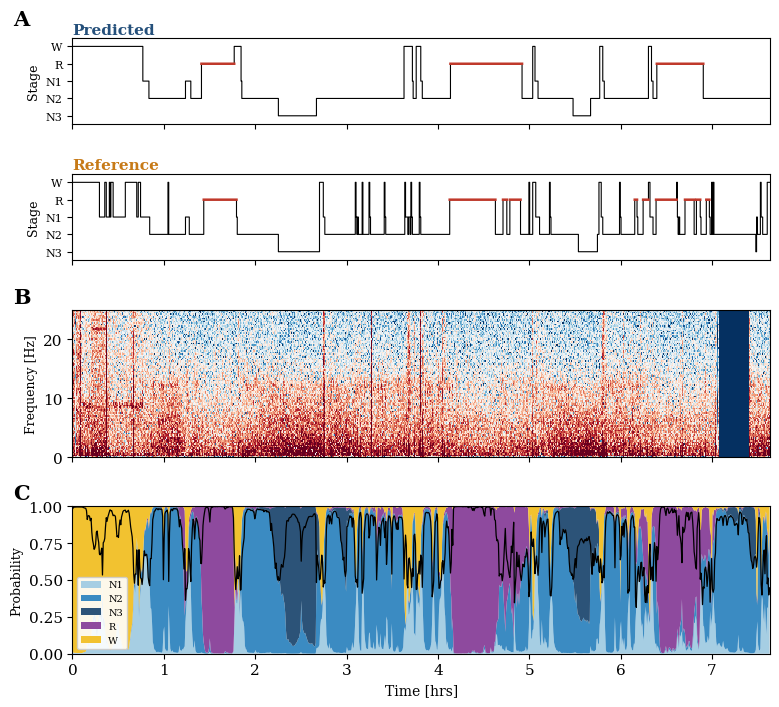

In [7]:
LADDER = np.array([4, 2, 1, 0, 3])                 # W,N1,N2,N3,R -> ladder rows (W top, N3 bottom)
YT = [0, 1, 2, 3, 4]; YL = ["N3", "N2", "N1", "R", "W"]
COL = {"N1": "#A6CEE3", "N2": "#3B8BC2", "N3": "#2C5378", "R": "#8E4A9E", "W": "#F2C230"}
te_hr = (np.arange(n_ep) + 0.5) * 30 / 3600.0
T = n_ep * 30 / 3600.0

plt.rcParams.update({"font.size": 11, "font.family": "serif"})
fig = plt.figure(figsize=(9, 8))
gs = gridspec.GridSpec(4, 1, height_ratios=[1, 1, 1.7, 1.7], hspace=0.42)

def hypno(ax, stages, tag, color):
    pos = LADDER[stages]
    ax.step(te_hr, pos, where="post", color="k", lw=0.8)
    rem = stages == 4
    if rem.any():
        p = np.where(rem, LADDER[stages].astype(float), np.nan)
        ax.step(te_hr, p, where="post", color="#C0392B", lw=1.8)
    ax.set_yticks(YT); ax.set_yticklabels(YL, fontsize=8); ax.set_ylim(-0.5, 4.5)
    ax.set_xlim(0, T); ax.set_ylabel("Stage", fontsize=9)
    ax.set_title(tag, loc="left", fontsize=11, fontweight="bold", color=color, pad=3)
    ax.tick_params(labelbottom=False)

axA1 = fig.add_subplot(gs[0]); hypno(axA1, pred, "Predicted", "#25507B")
axA2 = fig.add_subplot(gs[1]); hypno(axA2, ref, "Reference", "#C77A17")

axB = fig.add_subplot(gs[2])
vmin, vmax = np.percentile(Sdb, [5, 97])
axB.pcolormesh(t_hr, f[f <= 25.0], Sdb, cmap="RdBu_r", vmin=vmin, vmax=vmax, shading="auto")
axB.set_ylim(0, 25); axB.set_xlim(0, T); axB.set_ylabel("Frequency [Hz]", fontsize=9)
axB.tick_params(labelbottom=False)

axC = fig.add_subplot(gs[3])
order = ["N1", "N2", "N3", "R", "W"]; idx = {"N1": 1, "N2": 2, "N3": 3, "R": 4, "W": 0}
axC.stackplot(te_hr, *[sp[:, idx[k]] for k in order], colors=[COL[k] for k in order], labels=order)
axC.plot(te_hr, sp.max(1), color="k", lw=0.9)
axC.set_xlim(0, T); axC.set_ylim(0, 1); axC.set_ylabel("Probability", fontsize=9)
axC.set_xlabel("Time [hrs]", fontsize=10)
axC.legend(loc="lower left", ncol=1, fontsize=7, framealpha=0.9)

for ax, lab, yy in [(axA1, "A", 1.10), (axB, "B", 1.02), (axC, "C", 1.02)]:
    ax.text(-0.085, yy, lab, transform=ax.transAxes, fontsize=15, fontweight="bold", va="bottom")

fig.savefig(os.path.join(FIGDIR, "fig_hypnogram.pdf"), bbox_inches="tight", dpi=200)
fig.savefig(os.path.join(FIGDIR, "fig_hypnogram.png"), bbox_inches="tight", dpi=200)
# retain the underlying arrays so the figure can be regenerated without retraining
np.savez_compressed(os.path.join(FIGDIR, "hypnogram_data.npz"),
                    ref=ref, pred=pred, stage_probs=sp, apnea_prob=apn,
                    spec_db=Sdb, spec_f=f[f <= 25.0], spec_t=t_hr, subject=sid, acc=acc, kappa=kap)
print("saved fig_hypnogram.pdf/.png and hypnogram_data.npz  |  %s acc=%.3f" % (sid, acc))
plt.show()

epoch  1  train_loss=1.7917  val_acc=0.7280


epoch  5  train_loss=1.3826  val_acc=0.7220


epoch 10  train_loss=1.1975  val_acc=0.7016


epoch 15  train_loss=1.0889  val_acc=0.7083


epoch 20  train_loss=1.0098  val_acc=0.6963


...

epoch 30  train_loss=0.8754  val_acc=0.7058


epoch 35  train_loss=0.8420  val_acc=0.7080


epoch 40  train_loss=0.8158  val_acc=0.7070


epoch 45  train_loss=0.8107  val_acc=0.7082
logged 45 epochs in 100s


saved fig_training_curve.pdf/.png and training_curve_data.npz


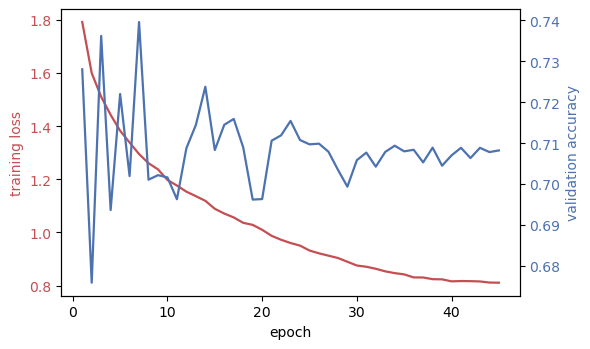

In [8]:
# ===== Training curve (instrumented single-fold run) =====
# Reuses MMFeatureNet, _windows, _sqrt_cw, subj_infer, data, subs, make_folds, DEV, L, SEED,
# FIGDIR defined in the cells above -- run those cells first. Trains ONE fold for a fixed 45
# epochs, logging train loss and validation accuracy each epoch, then plots and saves the curve.
# This is a separate single-fold run (~90 s); it does not touch the SN90 figure above.
import time
torch.manual_seed(SEED); np.random.seed(SEED)
_tr_all, _te = make_folds(subs, 10, seed=SEED)[0]
_rng = np.random.RandomState(100); _tr_all = list(_tr_all); _rng.shuffle(_tr_all)
_nv = max(10, len(_tr_all) // 9); _va, _tr = _tr_all[:_nv], _tr_all[_nv:]

Fe, Fc, Y, A, M = _windows(data, _tr, L // 2); N = Fe.shape[0]
net = MMFeatureNet(fusion="concat").to(DEV)
opt = torch.optim.AdamW(net.parameters(), lr=1e-3, weight_decay=1e-4)
EPOCHS = 45; sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
ce = nn.CrossEntropyLoss(weight=_sqrt_cw(data, _tr), reduction="none")
_ac = np.zeros(2, np.int64)
for s in _tr: _ac += np.bincount(data[s][3], minlength=2)
bce = nn.BCEWithLogitsLoss(reduction="none",
        pos_weight=torch.tensor([_ac[0] / max(1, _ac[1])], dtype=torch.float32, device=DEV))
bs = 32; ep_list, loss_list, vacc_list = [], [], []

t0 = time.time()
for ep in range(1, EPOCHS + 1):
    net.train(); perm = torch.randperm(N, device=DEV); tot, nb = 0.0, 0
    for i in range(0, N - bs + 1, bs):
        idx = perm[i:i+bs]; s_o, a_o = net(Fe[idx], Fc[idx]); m = M[idx].reshape(-1)
        ls = (ce(s_o.reshape(-1, 5), Y[idx].reshape(-1)) * m).sum() / m.sum().clamp(min=1)
        la = (bce(a_o.reshape(-1), A[idx].reshape(-1)) * m).sum() / m.sum().clamp(min=1)
        loss = ls + la
        opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(net.parameters(), 5.0); opt.step()
        tot += float(loss); nb += 1
    sch.step()
    vacc = float(np.mean([(subj_infer(net, data, s)[0].argmax(1) == data[s][2]).mean() for s in _va]))
    ep_list.append(ep); loss_list.append(tot / max(1, nb)); vacc_list.append(vacc)
    if ep == 1 or ep % 5 == 0:
        print(f"epoch {ep:2d}  train_loss={tot/max(1,nb):.4f}  val_acc={vacc:.4f}")
print(f"logged {EPOCHS} epochs in {time.time()-t0:.0f}s")

fig, ax1 = plt.subplots(figsize=(6, 3.6))
ax1.plot(ep_list, loss_list, color="#C44E52", lw=1.6)
ax1.set_xlabel("epoch"); ax1.set_ylabel("training loss", color="#C44E52")
ax1.tick_params(axis="y", labelcolor="#C44E52")
ax2 = ax1.twinx()
ax2.plot(ep_list, vacc_list, color="#4C72B0", lw=1.6)
ax2.set_ylabel("validation accuracy", color="#4C72B0")
ax2.tick_params(axis="y", labelcolor="#4C72B0")
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "fig_training_curve.pdf"), bbox_inches="tight", dpi=200)
fig.savefig(os.path.join(FIGDIR, "fig_training_curve.png"), bbox_inches="tight", dpi=200)
np.savez_compressed(os.path.join(FIGDIR, "training_curve_data.npz"),
                    epoch=ep_list, train_loss=loss_list, val_acc=vacc_list)
print("saved fig_training_curve.pdf/.png and training_curve_data.npz")
plt.show()